<a href="https://colab.research.google.com/github/li00140/ELSA-Depression-Classification/blob/main/SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import sys
!{sys.executable} -m pip install imbalanced-learn xgboost
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from collections import Counter
from pathlib import Path

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, balanced_accuracy_score
)
from sklearn.impute            import SimpleImputer

from xgboost                   import XGBClassifier

from imblearn.over_sampling    import SMOTE
from imblearn.under_sampling   import RandomUnderSampler
from imblearn.pipeline         import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
np.random.seed(42)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [45]:
DATA_DIR   = Path(".")
OUTPUT_DIR = Path("smote_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CESD_POS = ['PScedA','PScedB','PScedC','PScedE','PScedG','PScedH']
CESD_NEG = ['PScedD', 'PScedF']
CESD_ALL = CESD_POS + CESD_NEG
CESD_THRESHOLD = 4

# Core features
FEATURE_MAP = {
    'DiSex': 'Sex',     # Sex — no -1 values, clean
    'DiMar': 'Marital Status',     # Marital status — -1→NaN, -8/-9→NaN
    'DiMaedu': 'Education',   # Education — -8/-9→NaN

    # Physical health
    'Hehelf': 'Self-rated health',    # Self-rated health — -1→NaN, -8/-9→NaN
    'Heill': 'Long-standing illness',     # Long-standing illness — -8/-9→NaN only
    'Helim': 'Limits activities',     # Limits activities — -1→2 (no illness = not limited)
    'HePain': 'Pain',    # Pain — -1→NaN, -8/-9→NaN
    'HeSmk': 'Smoking',     # Smoking — -1→3 (never smoked = new category)
    'HeActa': 'Vigorous activity',    # Vigorous activity — -8/-9→NaN only
    'HeActb': 'Moderate activity',    # Moderate activity — -8/-9→NaN only
    'HeActc': 'Mild activity',    # Mild activity — -9→NaN only

    # CES-D-8 binary items + total (computed in Cell 2b)
    'PScedA_bin': 'CESD Depressed', 
    'PScedB_bin': 'CESD Effortful', 
    'PScedC_bin': 'CESD Restless sleep', 
    'PScedD_bin': 'CESD Happy (R)',
    'PScedE_bin': 'CESD Lonely', 
    'PScedF_bin': 'CESD Enjoyed life (R)', 
    'PScedG_bin': 'CESD Sad', 
    'PScedH_bin': 'CESD Could not get going',
    'PScedA': 'Depressed',
    'PScedB': 'Effortful',
    'PScedC': 'Restless sleep',
    'PScedD': 'Happy (R)',
    'PScedE': 'Lonely',
    'PScedF': 'Enjoyed life (R)',
    'PScedG': 'Sad',
    'PScedH': 'Could not get going',
    'cesd_total': 'CESD Total'
}

FEATURE_NAMES = list(FEATURE_MAP.keys())

MISSING_CODES = [-1, -8, -9]


In [46]:
import requests

# Helper function to resolve column names, assuming it looks for exact match or contains
def resolve_columns(all_cols, needed_cols):
    resolved = {}
    for nc in needed_cols:
        # First try exact match (case-insensitive for robustness)
        for ac in all_cols:
            if ac.lower() == nc.lower():
                resolved[nc] = ac
                break
        # If not found, try partial match (contains)
        if nc not in resolved:
            for ac in all_cols:
                if nc.lower() in ac.lower():
                    resolved[nc] = ac
                    break
    return resolved

In [47]:
def load_wave(wave_num, data_dir):
    fname = WAVE_FILES.get(wave_num)
    fpath = data_dir / fname
    if not fpath.exists():
        print(f"  [!] Wave {wave_num}: not found at {fpath}")
        return None

    all_cols  = pd.read_csv(fpath, nrows=0).columns.tolist()
    cesd_map  = resolve_columns(all_cols, CESD_ALL)
    feat_map  = resolve_columns(all_cols, list(FEATURE_MAP.values()))
    id_map    = resolve_columns(all_cols, ["idauniq"])

    needed = (list(cesd_map.values()) + list(feat_map.values()) + list(id_map.values()))

    if len(cesd_map) < 8:
        print(f"  [!] Wave {wave_num}: only {len(cesd_map)}/8 CES-D items — skipping")
        return None

    df = pd.read_csv(fpath, usecols=needed, low_memory=False)

    # Rename to canonical lower-case names
    rename = {v: k for k, v in cesd_map.items()}
    rename.update({v: k for k, v in id_map.items()})
    inv_feat = {v: k for k, v in FEATURE_MAP.items()}
    for raw_col, actual in feat_map.items():
        rename[actual] = inv_feat.get(raw_col, raw_col)
    df.rename(columns=rename, inplace=True)

    # Replace ELSA missing codes with NaN
    for col in CESD_ALL + FEATURE_NAMES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace(MISSING_CODES, np.nan)

    # CES-D score
    for col in CESD_POS:
        df[f"_{col}_s"] = (df[col] == 1).astype(float)
    for col in CESD_NEG:
        df[f"_{col}_s"] = (df[col] == 2).astype(float)

    score_cols    = [f"_{c}_s" for c in CESD_ALL]
    df["cesd_score"] = df[score_cols].sum(axis=1)
    df = df[df[CESD_ALL].notna().all(axis=1)].copy()
    df["depressed"] = (df["cesd_score"] >= CESD_THRESHOLD).astype(int)
    df["wave"]      = wave_num

    keep = ["idauniq","wave","cesd_score","depressed"] + FEATURE_NAMES
    return df[[c for c in keep if c in df.columns]]


def load_all_waves(data_dir):
    frames = []
    for w in sorted(WAVE_FILES.keys()):
        print(f"  Loading wave {w}...")
        df = load_wave(w, data_dir)
        if df is not None:
            frames.append(df)
            print(f"    -> {len(df):,} valid CES-D respondents | "
                  f"depressed: {df['depressed'].sum():,} "
                  f"({df['depressed'].mean()*100:.1f}%)")
    combined = pd.concat(frames, ignore_index=True)
    print(f"\n  Total pooled: {len(combined):,} observations across {len(frames)} waves\n")
    return combined

In [48]:
def investigate_imbalance(df):
    print("\n" + "=" * 60)
    print("SECTION 1: CLASS IMBALANCE INVESTIGATION")
    print("=" * 60)

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("ELSA Depression (CES-D >= 4) — Class Imbalance Investigation",
                 fontsize=14, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

    counts = df["depressed"].value_counts().sort_index()
    ir     = counts[0] / counts[1]

    # Overall bar
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(["Not Depressed\n(CES-D < 4)", "Depressed\n(CES-D >= 4)"],
                   counts.values, color=["#4878CF","#D65F5F"],
                   edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + counts.max()*0.02,
                 f"{val:,}\n({val/len(df)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax1.set_title("Overall Class Distribution", fontweight="bold")
    ax1.set_ylabel("Count")
    ax1.annotate(f"Imbalance Ratio: {ir:.2f}:1",
                 xy=(0.5, 0.92), xycoords="axes fraction", ha="center",
                 fontsize=9, color="darkred",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFE4E4"))

    # Per-wave bar
    ax2 = fig.add_subplot(gs[0, 1])
    ws = df.groupby("wave")["depressed"].agg(total="count", dep="sum")
    ws["ndep"] = ws["total"] - ws["dep"]
    x, bw = np.arange(len(ws)), 0.35
    ax2.bar(x - bw/2, ws["ndep"], bw, label="Not Depressed", color="#4878CF", alpha=0.85)
    ax2.bar(x + bw/2, ws["dep"],  bw, label="Depressed",     color="#D65F5F", alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"W{w}" for w in ws.index], fontsize=9)
    ax2.set_title("Class Distribution by Wave", fontweight="bold")
    ax2.set_ylabel("Count"); ax2.legend(fontsize=8)

    # Prevalence trend
    ax3 = fig.add_subplot(gs[0, 2])
    ws["pct"] = ws["dep"] / ws["total"] * 100
    ax3.plot(ws.index, ws["pct"], marker="o", color="#D65F5F", lw=2, ms=7)
    ax3.fill_between(ws.index, ws["pct"], alpha=0.12, color="#D65F5F")
    ax3.axhline(df["depressed"].mean()*100, color="gray", ls="--", lw=1, label="Mean")
    ax3.set_title("Depression Prevalence (%) by Wave", fontweight="bold")
    ax3.set_xlabel("Wave"); ax3.set_ylabel("Prevalence (%)")
    ax3.legend(fontsize=8); ax3.set_xticks(ws.index)

    # CES-D score histogram
    ax4 = fig.add_subplot(gs[1, 0])
    sd     = df["cesd_score"].value_counts().sort_index()
    colors = ["#D65F5F" if s >= CESD_THRESHOLD else "#4878CF" for s in sd.index]
    ax4.bar(sd.index, sd.values, color=colors, edgecolor="white", lw=0.8)
    ax4.axvline(CESD_THRESHOLD - 0.5, color="black", ls="--", lw=1.5)
    ax4.set_title("CES-D Score Distribution", fontweight="bold")
    ax4.set_xlabel("CES-D Score (0-8)"); ax4.set_ylabel("Count")
    from matplotlib.patches import Patch
    ax4.legend(handles=[
        Patch(color="#4878CF", label="Not Depressed"),
        Patch(color="#D65F5F", label="Depressed"),
        plt.Line2D([0],[0], color="black", ls="--", label="Cut-off (4)")
    ], fontsize=8)

    # By sex
    ax5 = fig.add_subplot(gs[1, 1])
    df_s = df.dropna(subset=["sex"])
    sex_dep = df_s.groupby(["sex","depressed"]).size().unstack(fill_value=0)
    sex_dep.index = ["Male","Female"]
    (sex_dep.div(sex_dep.sum(axis=1),axis=0)*100).plot(
        kind="bar", ax=ax5, color=["#4878CF","#D65F5F"],
        edgecolor="white", rot=0, legend=False)
    ax5.set_title("Class Distribution by Sex (%)", fontweight="bold")
    ax5.set_ylabel("Percentage (%)")
    ax5.legend(["Not Depressed","Depressed"], fontsize=8)
    for c in ax5.containers: ax5.bar_label(c, fmt="%.1f%%", fontsize=8)

    # By age group
    ax6 = fig.add_subplot(gs[1, 2])
    df_a = df.dropna(subset=["age"]).copy()
    df_a["age_grp"] = pd.cut(df_a["age"], bins=[49,59,69,79,120],
                              labels=["50-59","60-69","70-79","80+"])
    age_dep = df_a.groupby(["age_grp","depressed"]).size().unstack(fill_value=0)
    (age_dep.div(age_dep.sum(axis=1),axis=0)*100).plot(
        kind="bar", ax=ax6, color=["#4878CF","#D65F5F"],
        edgecolor="white", rot=0, legend=False)
    ax6.set_title("Class Distribution by Age Group (%)", fontweight="bold")
    ax6.set_ylabel("Percentage (%)")
    ax6.legend(["Not Depressed","Depressed"], fontsize=8)
    for c in ax6.containers: ax6.bar_label(c, fmt="%.1f%%", fontsize=8)

    plt.savefig(OUTPUT_DIR/"1_imbalance_investigation.png", dpi=150, bbox_inches="tight")
    plt.close()

    total, n_dep = len(df), df["depressed"].sum()
    n_not = total - n_dep
    print(f"\n  Total observations : {total:,}")
    print(f"  Not Depressed (0)  : {n_not:,}  ({n_not/total*100:.1f}%)")
    print(f"  Depressed (1)      : {n_dep:,}  ({n_dep/total*100:.1f}%)")
    print(f"  Imbalance Ratio    : {n_not/n_dep:.2f}:1")
    print(f"  -> Saved: 1_imbalance_investigation.png")

In [49]:
def prepare_xy(df):
    avail = [f for f in FEATURE_NAMES if f in df.columns]
    df_m  = df[avail + ["depressed"]].dropna()
    X = df_m[avail].values.astype(float)
    y = df_m["depressed"].values.astype(int)
    print(f"\n  Modelling dataset : {len(df_m):,} complete cases")
    print(f"  Features used     : {avail}")
    print(f"  Class balance     : {Counter(y)}")
    return X, y, avail

In [50]:
SMOTE_METHODS = {
    "No Resampling":       None,
    "Random Undersample":  RandomUnderSampler(random_state=42),
    "SMOTE":               SMOTE(random_state=42, k_neighbors=5),
}


def compare_smote_methods(X_train, y_train, X_test, y_test, feat_names):
    print("\n" + "=" * 60)
    print("SECTION 2: SMOTE VARIANT COMPARISON")
    print("=" * 60)

    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(X_train)
    Xte_sc = scaler.transform(X_test)
    results = []

    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    for name, sampler in SMOTE_METHODS.items():
        print(f"\n  [{name}]")
        if sampler:
            Xr, yr = sampler.fit_resample(Xtr_sc, y_train)
        else:
            Xr, yr = Xtr_sc.copy(), y_train.copy()
        print(f"    Resampled dist : {Counter(yr)}")

        for clf_name, clf in [
            ("XGBoost",      XGBClassifier(n_estimators=100, random_state=42,
                                           scale_pos_weight=scale_pos,
                                           eval_metric="logloss",
                                           verbosity=0)),
            ("RandomForest", RandomForestClassifier(n_estimators=100, random_state=42,
                                                    class_weight="balanced")),
        ]:
            clf.fit(Xr, yr)
            yp   = clf.predict(Xte_sc)
            prob = clf.predict_proba(Xte_sc)[:, 1]
            roc = roc_auc_score(y_test, prob)
            ap  = average_precision_score(y_test, prob)
            f1  = f1_score(y_test, yp)
            ba  = balanced_accuracy_score(y_test, yp)
            print(f"    {clf_name:15s}| ROC-AUC={roc:.3f}  F1={f1:.3f}  "
                  f"BalAcc={ba:.3f}  AP={ap:.3f}")
            results.append({
                "Resampling Method": name, "Classifier": clf_name,
                "ROC-AUC": round(roc,3), "F1 (minority)": round(f1,3),
                "Balanced Accuracy": round(ba,3), "Avg Precision": round(ap,3),
                "Majority N": Counter(yr)[0], "Minority N": Counter(yr)[1],
            })

    return pd.DataFrame(results)


def plot_smote_comparison(results_df, out_file="2_smote_comparison.png", title=None):
    metrics = ["ROC-AUC","F1 (minority)","Balanced Accuracy","Avg Precision"]

    clfs = results_df["Classifier"].unique()
    n_clfs = len(clfs)
    n_methods = results_df["Resampling Method"].nunique()
    bar_height = 0.75 / n_clfs
    palette = sns.color_palette("Set2", n_methods)

    method_order = (results_df.groupby("Resampling Method")[metrics[0]]
                    .mean().sort_values().index.tolist())

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle(title or "SMOTE Variant Comparison — ELSA Depression Classification",
                 fontsize=13, fontweight="bold")

    for ax, metric in zip(axes.flatten(), metrics):
        for i, clf in enumerate(clfs):
            sub = (results_df[results_df["Classifier"] == clf]
                   .set_index("Resampling Method")
                   .loc[method_order])
            offset = (i - (n_clfs - 1) / 2) * bar_height
            ax.barh(np.arange(n_methods) + offset, sub[metric],
                    height=bar_height, label=clf,
                    color=palette[:n_methods],
                    alpha=0.9 if i == 0 else 0.6,
                    edgecolor="white", linewidth=0.5)

        ax.set_yticks(np.arange(n_methods))
        ax.set_yticklabels(method_order, fontsize=9)
        ax.set_xlim(left=0)
        ax.set_title(metric, fontweight="bold")
        if metric == metrics[0]:
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / out_file, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"\n  -> Saved: {out_file}")

  Wave 6: 9,845 valid CES-D respondents | depressed: 1,314 (13.3%)
  Wave 7: 8,942 valid CES-D respondents | depressed: 1,159 (13.0%)

  Total pooled: 18,787 observations


  Modelling dataset : 2,368 complete cases
  Features used     : ['DiSex', 'DiMar', 'DiMaedu', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc', 'PScedA', 'PScedB', 'PScedC', 'PScedD', 'PScedE', 'PScedF', 'PScedG', 'PScedH']
  Class balance     : Counter({np.int64(0): 1944, np.int64(1): 424})

SECTION 2: SMOTE VARIANT COMPARISON

  [No Resampling]
    Resampled dist : Counter({np.int64(0): 1555, np.int64(1): 339})
    XGBoost        | ROC-AUC=1.000  F1=0.977  BalAcc=0.990  AP=0.998
    RandomForest   | ROC-AUC=1.000  F1=0.976  BalAcc=0.981  AP=0.998

  [Random Undersample]
    Resampled dist : Counter({np.int64(0): 339, np.int64(1): 339})
    XGBoost        | ROC-AUC=1.000  F1=0.944  BalAcc=0.987  AP=0.999
    RandomForest   | ROC-AUC=0.999  F1=0.929  BalAcc=0.983  AP=0.995

  [SMOTE]
    

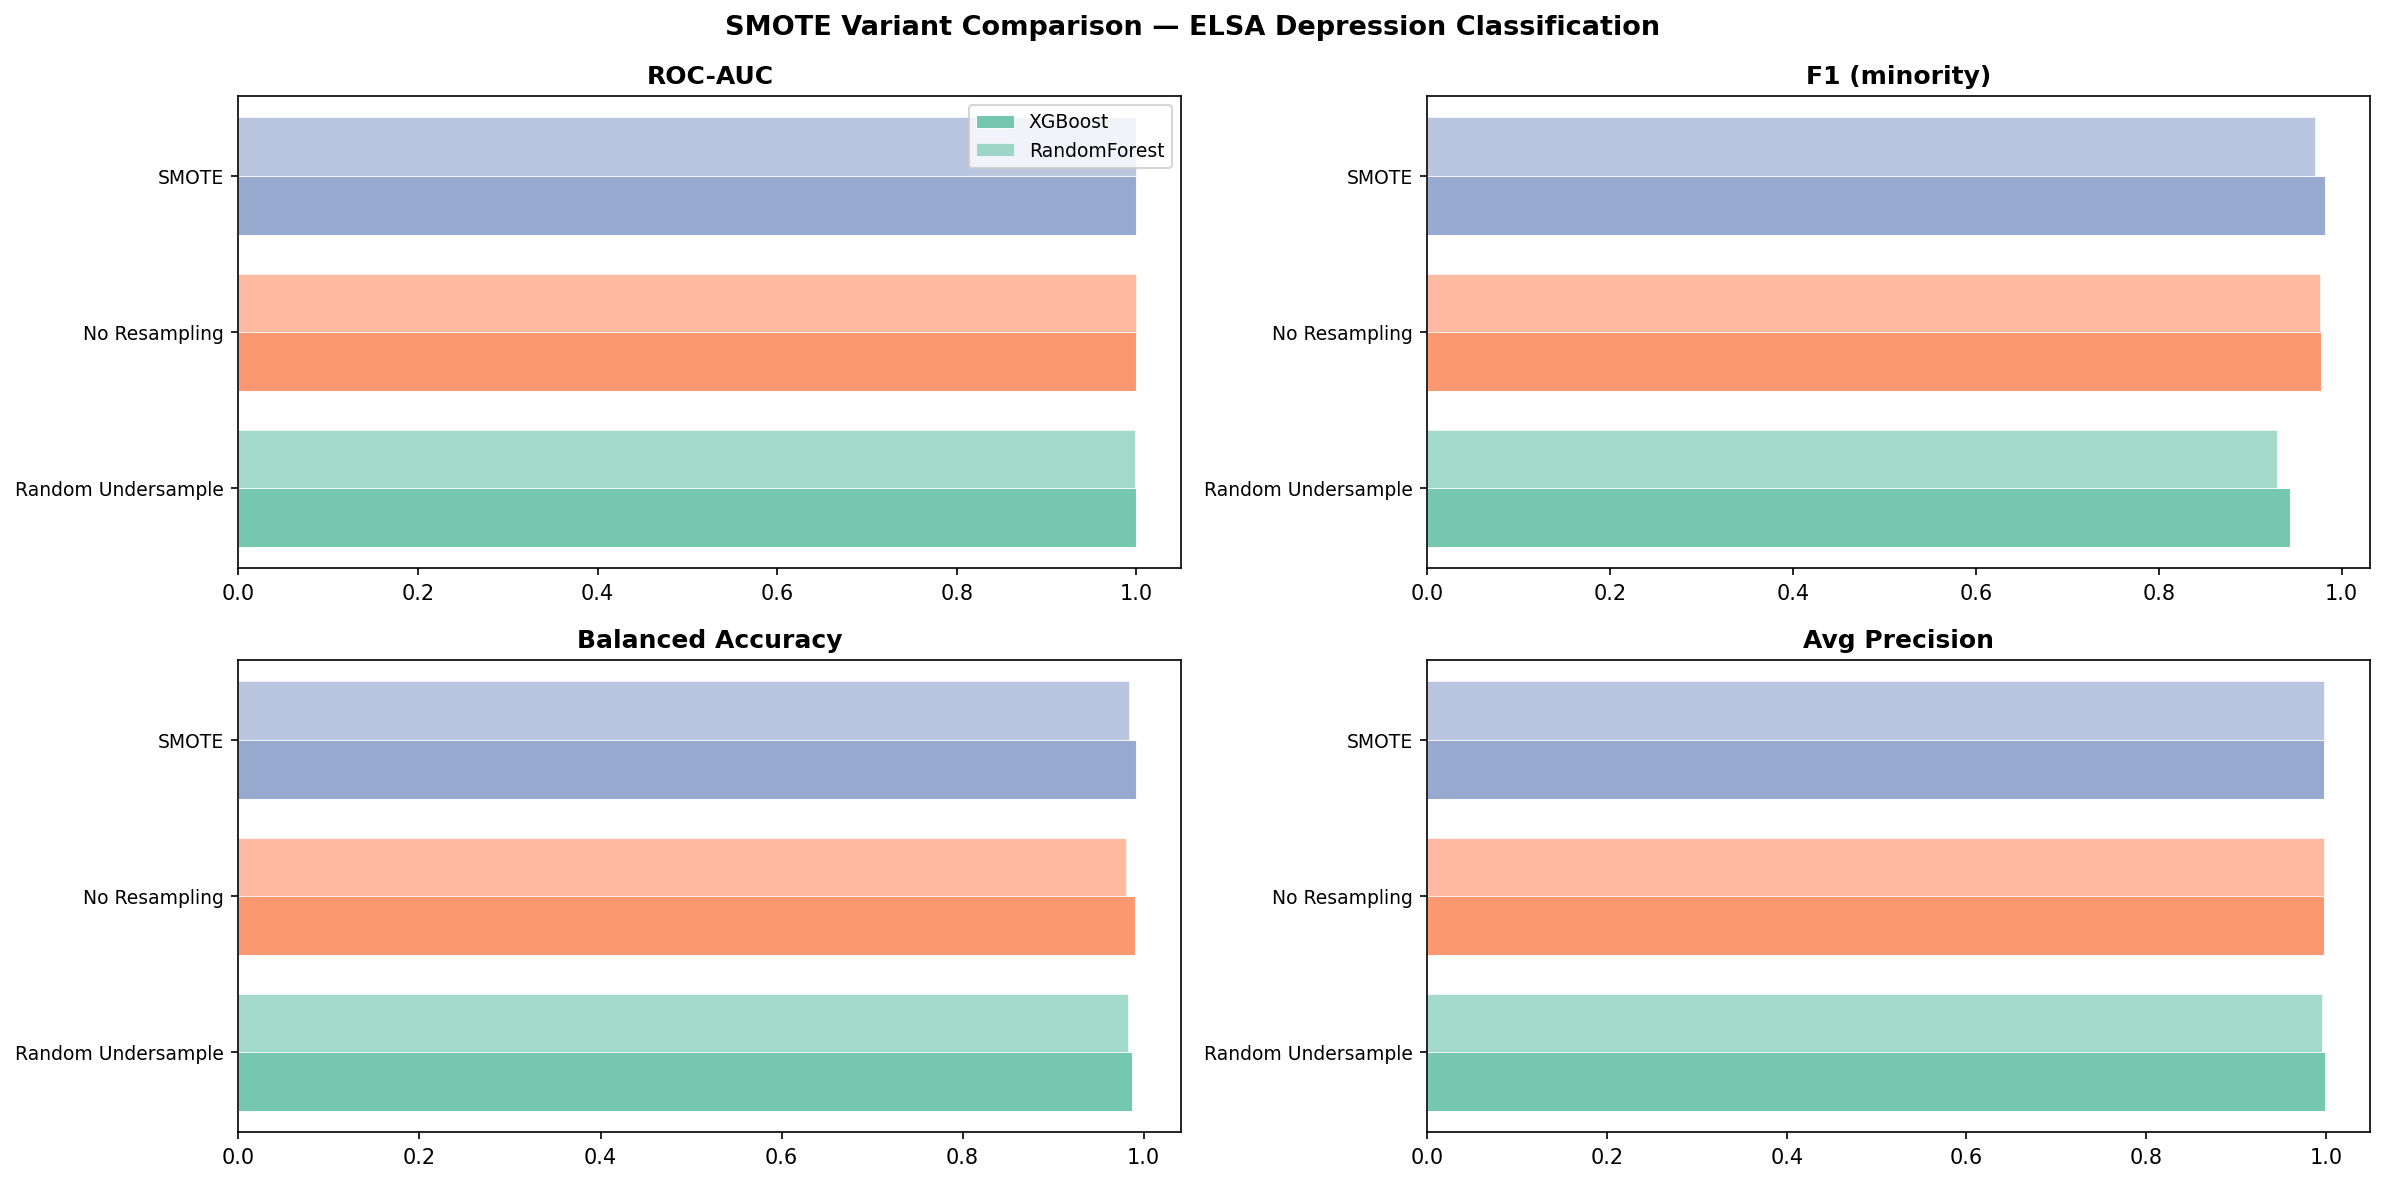

In [51]:
w6 = pd.read_stata('./ELSA_Dataset/wave_6_elsa_data_v2.dta', convert_categoricals=False)
w7 = pd.read_stata('./ELSA_Dataset/wave_7_elsa_data.dta', convert_categoricals=False)

def process_wave(raw_df, wave_num):
    all_cols = raw_df.columns.tolist()
    cesd_map = resolve_columns(all_cols, CESD_ALL)
    feat_map = resolve_columns(all_cols, list(FEATURE_MAP.keys()))
    id_map   = resolve_columns(all_cols, ["idauniq"])

    if len(cesd_map) < 8:
        print(f"  [!] Wave {wave_num}: only {len(cesd_map)}/8 CES-D items — skipping")
        return None

    # deduplicate to avoid selecting the same column twice
    needed = list(dict.fromkeys(
        list(cesd_map.values()) + list(feat_map.values()) + list(id_map.values())
    ))
    df = raw_df[[c for c in needed if c in raw_df.columns]].copy()

    rename = {v: k for k, v in cesd_map.items()}
    rename.update({v: k for k, v in id_map.items()})
    rename.update({v: k for k, v in feat_map.items()})
    df.rename(columns=rename, inplace=True)

    for col in CESD_ALL + FEATURE_NAMES:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].replace(MISSING_CODES, np.nan)

    for col in CESD_POS:
        df[f"_{col}_s"] = (df[col] == 1).astype(float)
    for col in CESD_NEG:
        df[f"_{col}_s"] = (df[col] == 2).astype(float)

    df["cesd_score"] = df[[f"_{c}_s" for c in CESD_ALL]].sum(axis=1)
    df = df[df[CESD_ALL].notna().all(axis=1)].copy()
    df["depressed"] = (df["cesd_score"] >= CESD_THRESHOLD).astype(int)
    df["wave"] = wave_num

    keep = ["idauniq", "wave", "cesd_score", "depressed"] + FEATURE_NAMES
    result = df[[c for c in keep if c in df.columns]]
    print(f"  Wave {wave_num}: {len(result):,} valid CES-D respondents | "
          f"depressed: {result['depressed'].sum():,} ({result['depressed'].mean()*100:.1f}%)")
    return result

frames = [process_wave(w6, 6), process_wave(w7, 7)]
df = pd.concat([f for f in frames if f is not None], ignore_index=True)
print(f"\n  Total pooled: {len(df):,} observations\n")

X, y, feat_names = prepare_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results_df = compare_smote_methods(X_train, y_train, X_test, y_test, feat_names)

plot_smote_comparison(results_df)

from IPython.display import Image, display
display(Image(filename=OUTPUT_DIR / "2_smote_comparison.png"))


  Modelling dataset : 2,368 complete cases
  Features used     : ['DiSex', 'DiMar', 'DiMaedu', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc']
  Class balance     : Counter({np.int64(0): 1944, np.int64(1): 424})

SECTION 2: SMOTE VARIANT COMPARISON

  [No Resampling]
    Resampled dist : Counter({np.int64(0): 1555, np.int64(1): 339})
    XGBoost        | ROC-AUC=0.687  F1=0.343  BalAcc=0.598  AP=0.319
    RandomForest   | ROC-AUC=0.690  F1=0.307  BalAcc=0.579  AP=0.334

  [Random Undersample]
    Resampled dist : Counter({np.int64(0): 339, np.int64(1): 339})
    XGBoost        | ROC-AUC=0.672  F1=0.367  BalAcc=0.619  AP=0.298
    RandomForest   | ROC-AUC=0.714  F1=0.411  BalAcc=0.658  AP=0.339

  [SMOTE]
    Resampled dist : Counter({np.int64(0): 1555, np.int64(1): 1555})
    XGBoost        | ROC-AUC=0.671  F1=0.371  BalAcc=0.620  AP=0.319
    RandomForest   | ROC-AUC=0.698  F1=0.327  BalAcc=0.591  AP=0.366

  -> Saved: 3_smote_comparison_no_CESD.png


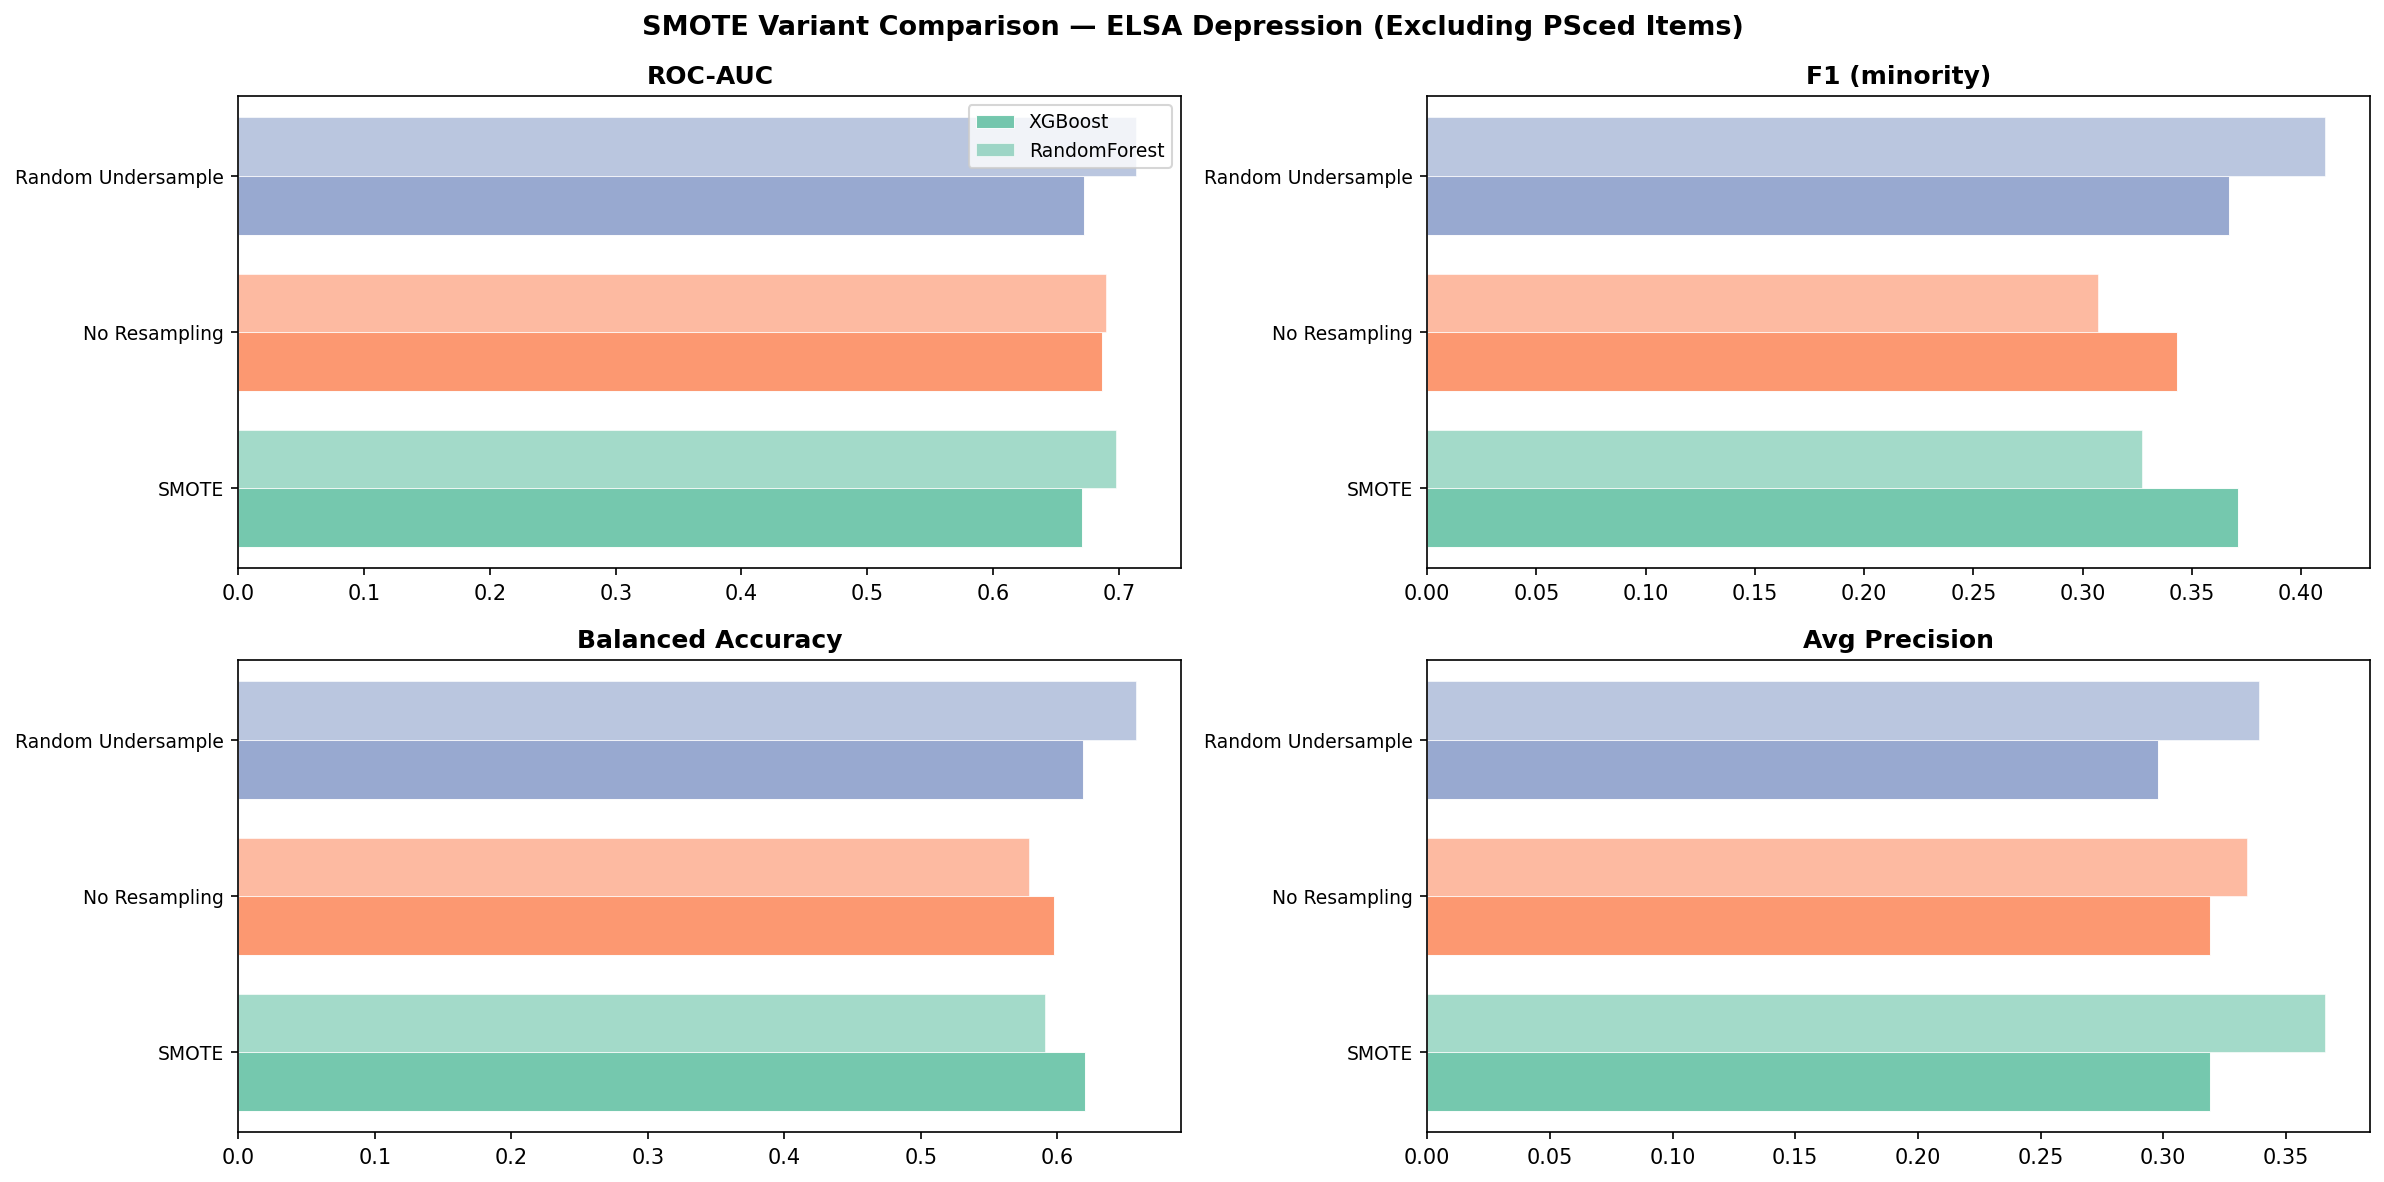

In [ ]:
CESD_COLS = ['PScedA','PScedB','PScedC','PScedD','PScedE','PScedF','PScedG','PScedH']

df_no_psced = df.drop(columns=[c for c in CESD_COLS if c in df.columns])

X_np, y_np, feat_names_np = prepare_xy(df_no_psced)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

results_df_no_psced = compare_smote_methods(
    X_train_np, y_train_np, X_test_np, y_test_np, feat_names_np
)

plot_smote_comparison(
    results_df_no_psced,
    out_file="3_smote_comparison_no_CESD.png",
    title="SMOTE Variant Comparison — ELSA Depression (Excluding CESD Items)"
)

from IPython.display import Image, display
display(Image(filename=OUTPUT_DIR / "3_smote_comparison_no_CESD.png"))